# 03. Analisis exploratorio del dataset limpio

Este notebook desarrolla el analisis exploratorio del conjunto de convocatorias limpias de SICOES. Se utiliza `parquet` como fuente principal y se generan figuras reutilizables para la monografia en `outputs/figures/`.

## Objetivos del EDA

- describir la estructura y el tamano del dataset
- identificar valores faltantes y registros duplicados
- verificar la unicidad del identificador `cuce`
- analizar distribuciones por categoria y por fecha
- explorar frecuencia de palabras y longitud de textos
- producir graficos listos para documentacion academica


In [1]:
from __future__ import annotations

import re
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
try:
    from wordcloud import WordCloud
except ModuleNotFoundError:
    WordCloud = None

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROCESSED_PARQUET_PATH = ROOT / "data" / "processed" / "sicoes_convocatorias_clean.parquet"
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(filename: str) -> None:
    """Guarda la figura activa con configuracion consistente para documentacion."""
    output_path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    print(f"Figura guardada en: {output_path}")


def strip_accents(value: str) -> str:
    """Elimina acentos para unificar variantes del mismo termino."""
    normalized = unicodedata.normalize("NFKD", value)
    return "".join(char for char in normalized if not unicodedata.combining(char))


def tokenize_raw_text(series: pd.Series) -> list[str]:
    """Tokeniza texto en bruto para comparar contra la version normalizada."""
    text = " ".join(series.fillna("").astype(str).str.lower().tolist())
    return re.findall(r"[a-zA-ZáéíóúñüÁÉÍÓÚÑÜ0-9]+", text)


def normalize_text(series: pd.Series) -> list[str]:
    """Normaliza texto para un analisis de frecuencia mas interpretable."""
    text = " ".join(series.fillna("").astype(str).str.lower().tolist())
    text = text.replace("const.", "construccion ")
    text = re.sub(r"\bconst\b", "construccion", text)
    raw_tokens = re.findall(r"[a-zA-ZáéíóúñüÁÉÍÓÚÑÜ0-9]+", text)

    stopwords = {
        "del", "las", "los", "una", "uno", "unos", "unas", "para", "por", "con",
        "sin", "que", "como", "sobre", "entre", "desde", "hasta", "ante", "bajo",
        "cabe", "contra", "tras", "durante", "mediante", "segun", "sicoes", "bolivia",
        "gobierno", "autonomo", "municipal", "nacional", "regional", "salud", "caja",
        "servicio", "publica", "publico", "departamental", "convocatoria", "contratacion",
        "entidad", "proceso", "adquisicion", "de", "la", "el", "y", "en", "a", "se",
        "al", "un", "es", "su", "lo", "las", "los"
    }
    domain_noise = {
        "gestion", "municipio", "sus", "san", "santa", "item", "items", "lote", "lotes",
        "unidad", "programa", "proyecto", "sistema", "servicios", "general", "generales",
        "bien", "bienes", "obra", "obras"
    }

    tokens: list[str] = []
    for token in raw_tokens:
        token = strip_accents(token)
        if token.isdigit():
            continue
        if re.fullmatch(r"20\d{2}", token):
            continue
        if len(token) < 4:
            continue
        if token in stopwords or token in domain_noise:
            continue
        tokens.append(token)

    return tokens


df = pd.read_parquet(PROCESSED_PARQUET_PATH)
df["fecha_publicacion_dt"] = pd.to_datetime(df["fecha_publicacion_iso"], errors="coerce")
df["fecha_presentacion_dt"] = pd.to_datetime(df["fecha_presentacion_iso"], errors="coerce")

df.head()


,document_id,cuce,entidad,tipo_contratacion,modalidad,objeto_contratacion,subasta,fecha_publicacion,fecha_presentacion,fecha_publicacion_iso,fecha_presentacion_iso,estado,archivos_disponibles,ficha_url,source_draw,source_row_in_page,longitud_objeto,cantidad_palabras_objeto,fecha_publicacion_dt,fecha_presentacion_dt
0,26-1101-00-1669685-1-1,26-1101-00-1669685-1-1,Gobierno Autonomo Municipal De Sucre,Obras,ANPP,Construccion Escalinata J.V. Patria Nueva,Sí,26/06/2026,08/07/2026,2026-06-26,2026-07-08,Vigente,Especificaciones Tecnicas; Especificaciones Te...,https://www.sicoes.gob.bo/portal/contratacione...,1,0,41,5,2026-06-26,2026-07-08
1,26-0417-03-1669697-1-1,26-0417-03-1669697-1-1,Caja Nacional De Salud Regional Santa Cruz,Bienes,CNC,Adquisicion De Medicamentos Regional Santa Cru...,Sí,26/06/2026,01/07/2026,2026-06-26,2026-07-01,Vigente,,https://www.sicoes.gob.bo/portal/contratacione...,1,1,101,15,2026-06-26,2026-07-01
2,26-0417-03-1669695-1-1,26-0417-03-1669695-1-1,Caja Nacional De Salud Regional Santa Cruz,Bienes,CNC,Adquisicion De Medicamentos Para Abastecimient...,Sí,26/06/2026,01/07/2026,2026-06-26,2026-07-01,Vigente,,https://www.sicoes.gob.bo/portal/contratacione...,1,2,108,15,2026-06-26,2026-07-01
3,26-0418-07-1669627-1-1,26-0418-07-1669627-1-1,Caja Petrolera De Salud Administracion Departa...,Bienes,ANPP,Adquisicion De Tacrolimus. Unidad De Farmacia ...,Sí,26/06/2026,08/07/2026,2026-06-26,2026-07-08,Vigente,Documento Base de Contratacion; Convocatoria,https://www.sicoes.gob.bo/portal/contratacione...,1,3,50,7,2026-06-26,2026-07-08
4,26-1205-00-1647943-2-1,26-1205-00-1647943-2-1,Gobierno Autonomo Municipal De El Alto,Obras,ANPE,Const. Piso De Acera En Area De Equipamiento S...,Sí,26/06/2026,07/07/2026,2026-06-26,2026-07-07,Vigente,Documento Base de Contratacion; Convocatoria; ...,https://www.sicoes.gob.bo/portal/contratacione...,1,4,62,12,2026-06-26,2026-07-07


## 1. Vista general del dataset


In [2]:
print(f"Ruta del dataset: {PROCESSED_PARQUET_PATH}")
print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print("\nColumnas disponibles:")
print(df.columns.tolist())

summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns],
})
summary


Ruta del dataset: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/data/processed/sicoes_convocatorias_clean.parquet
Filas: 1,429
Columnas: 20

Columnas disponibles:
['document_id', 'cuce', 'entidad', 'tipo_contratacion', 'modalidad', 'objeto_contratacion', 'subasta', 'fecha_publicacion', 'fecha_presentacion', 'fecha_publicacion_iso', 'fecha_presentacion_iso', 'estado', 'archivos_disponibles', 'ficha_url', 'source_draw', 'source_row_in_page', 'longitud_objeto', 'cantidad_palabras_objeto', 'fecha_publicacion_dt', 'fecha_presentacion_dt']


,dtype,missing,missing_pct,unique_values
document_id,object,0,0.00,1429
cuce,object,0,0.00,1429
entidad,object,0,0.00,319
tipo_contratacion,object,0,0.00,4
modalidad,object,0,0.00,8
objeto_contratacion,object,0,0.00,1427
subasta,object,0,0.00,2
fecha_publicacion,object,0,0.00,52
fecha_presentacion,object,0,0.00,28
fecha_publicacion_iso,object,0,0.00,52


## 2. Calidad de datos

Se revisan registros duplicados, unicidad de `cuce` y valores faltantes por columna.


In [3]:
row_duplicates = int(df.duplicated().sum())
cuce_duplicates = int(df["cuce"].duplicated().sum())
unique_cuce_ratio = df["cuce"].nunique(dropna=True) / len(df)

print(f"Registros completamente duplicados: {row_duplicates}")
print(f"CUCE duplicados: {cuce_duplicates}")
print(f"Proporcion de CUCE unicos: {unique_cuce_ratio:.4f}")

missing_df = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values(["missing_count", "missing_pct"], ascending=False)
)
missing_df


Registros completamente duplicados: 0
CUCE duplicados: 0
Proporcion de CUCE unicos: 1.0000


,missing_count,missing_pct
fecha_presentacion_dt,28,1.96
fecha_publicacion_dt,3,0.21
document_id,0,0.00
cuce,0,0.00
entidad,0,0.00
tipo_contratacion,0,0.00
modalidad,0,0.00
objeto_contratacion,0,0.00
subasta,0,0.00
fecha_publicacion,0,0.00


Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_missing_values.png


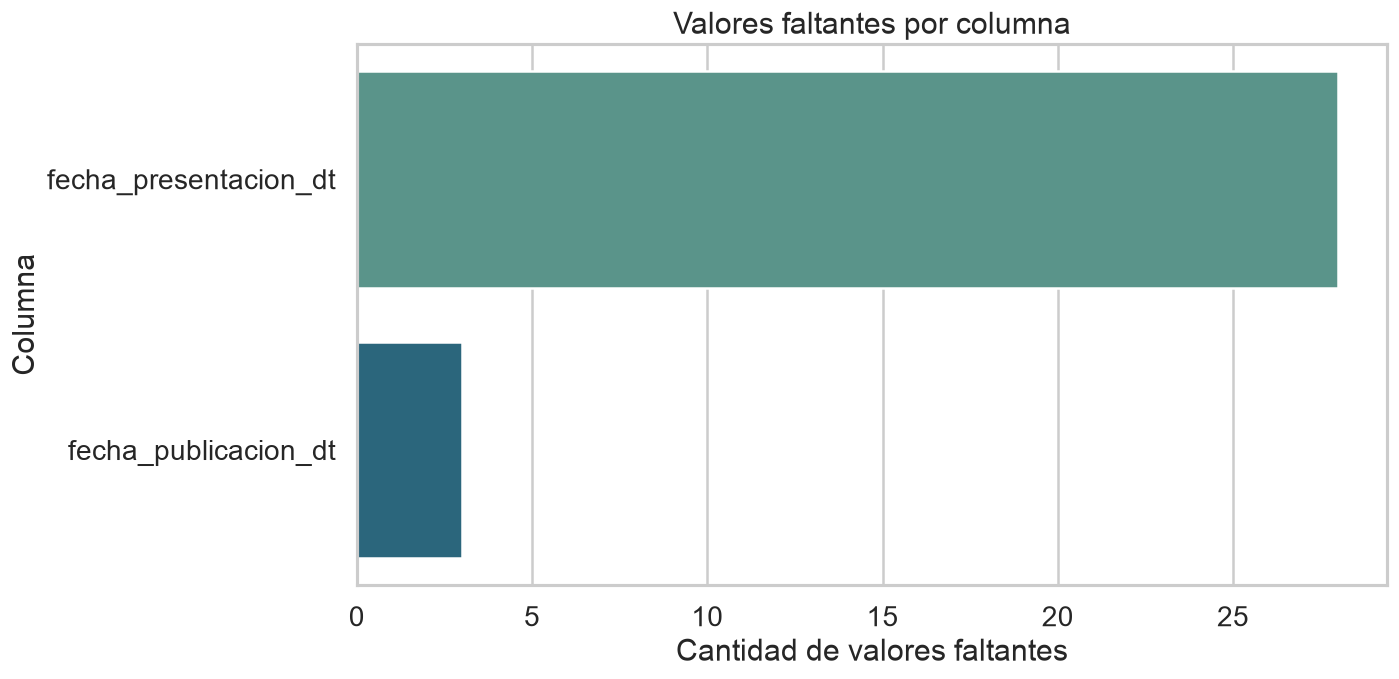

In [4]:
missing_plot = missing_df.reset_index().rename(columns={"index": "column"})
missing_plot = missing_plot[missing_plot["missing_count"] > 0]

if missing_plot.empty:
    print("No se detectaron valores faltantes nulos en el dataset.")
else:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=missing_plot, x="missing_count", y="column", hue="column", palette="crest", legend=False)
    plt.title("Valores faltantes por columna")
    plt.xlabel("Cantidad de valores faltantes")
    plt.ylabel("Columna")
    save_figure("eda_missing_values.png")
    plt.show()


## 3. Distribuciones por variables categoricas



Distribucion de tipo_contratacion:
     tipo_contratacion  cantidad
0               Bienes       961
1                Obras       196
2  Servicios Generales       166
3          Consultoría       106
Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_tipo_contratacion_distribution.png


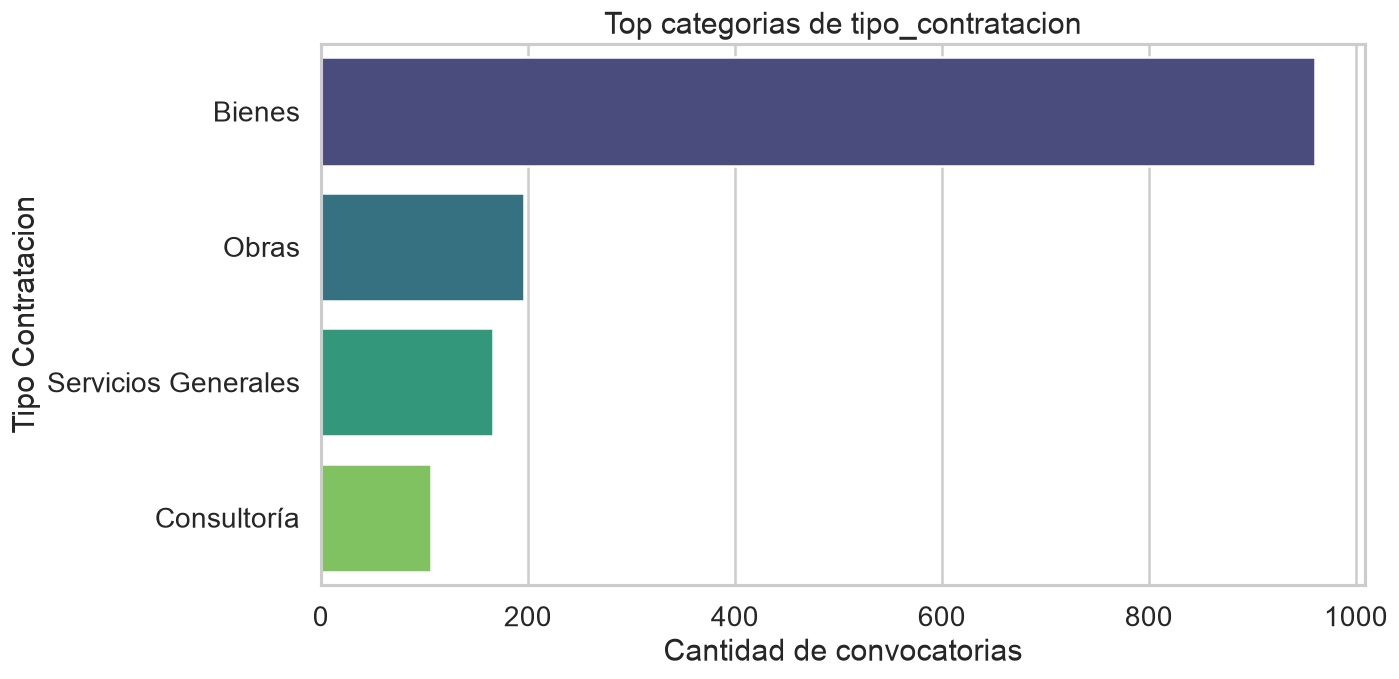


Distribucion de modalidad:
  modalidad  cantidad
0      ANPP       460
1      ANPE       433
2        CM       188
3       CNC       111
4        LP        94
5      CND1        75
6        OF        67
7        CD         1
Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_modalidad_distribution.png


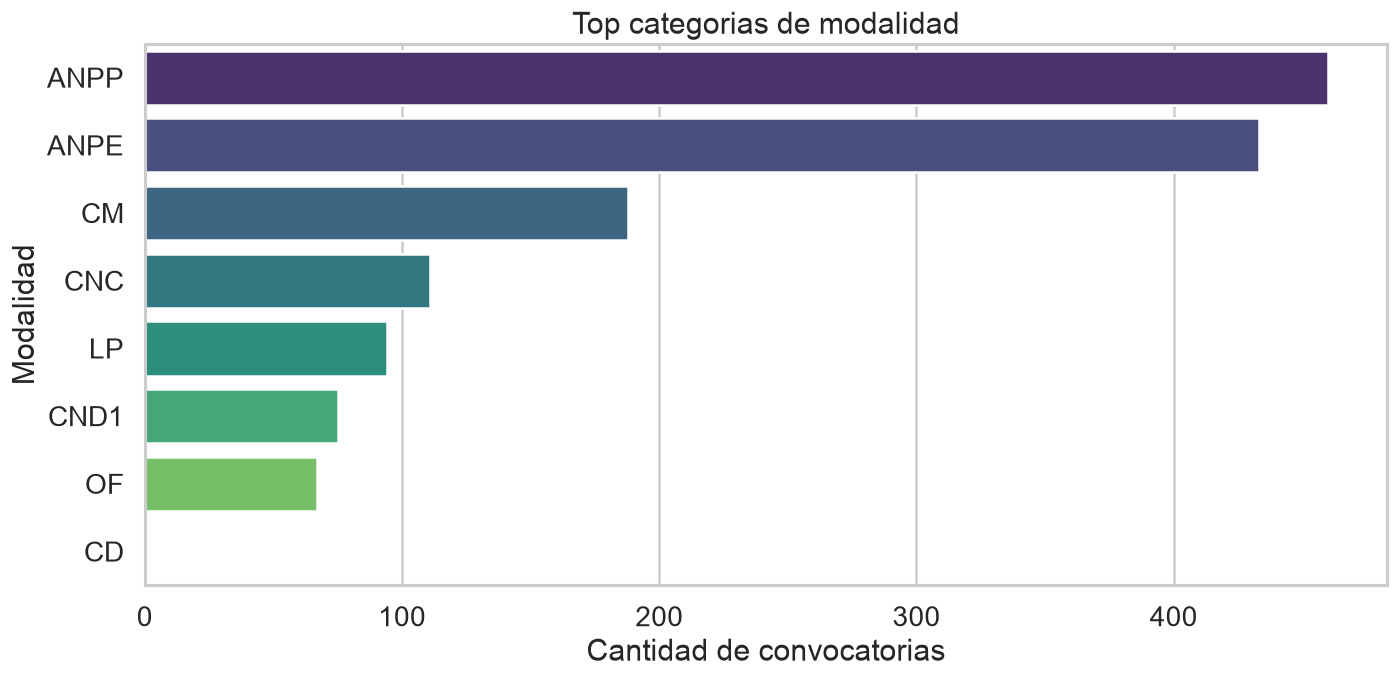


Distribucion de estado:
    estado  cantidad
0  Vigente      1429
Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_estado_distribution.png


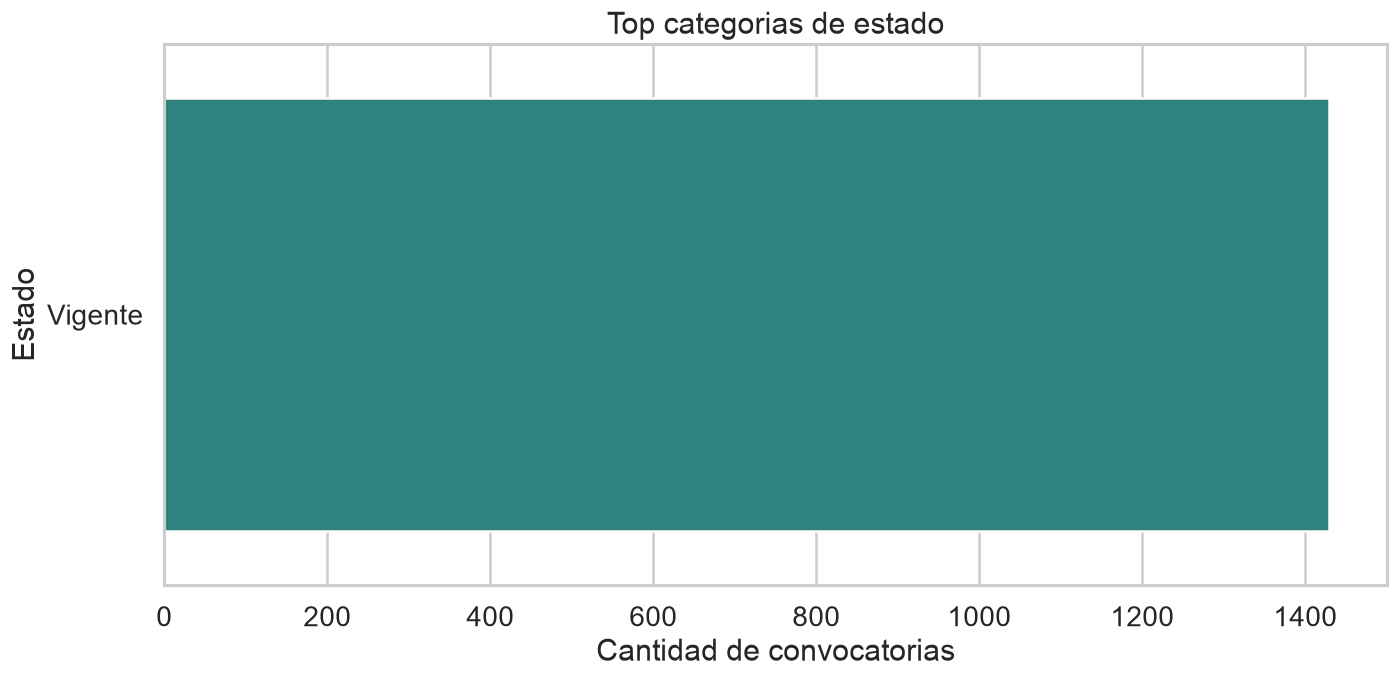


Distribucion de subasta:
  subasta  cantidad
0      Sí       992
1      No       437
Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_subasta_distribution.png


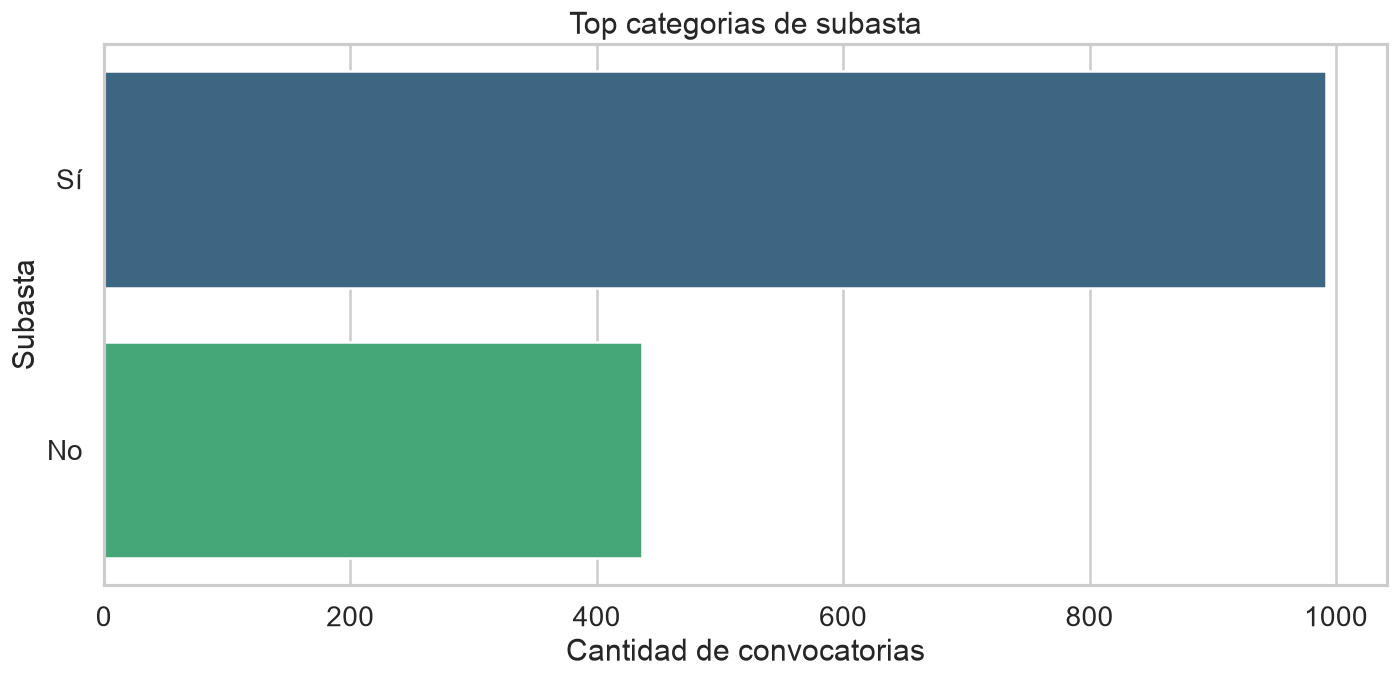

In [5]:
categorical_columns = ["tipo_contratacion", "modalidad", "estado", "subasta"]
for column in categorical_columns:
    display_df = df[column].fillna("No especificado").value_counts().head(10).reset_index()
    display_df.columns = [column, "cantidad"]
    print()
    print(f"Distribucion de {column}:")
    print(display_df)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=display_df, x="cantidad", y=column, hue=column, palette="viridis", legend=False)
    plt.title(f"Top categorias de {column}")
    plt.xlabel("Cantidad de convocatorias")
    plt.ylabel(column.replace("_", " ").title())
    save_figure(f"eda_{column}_distribution.png")
    plt.show()


Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_top_entidades.png


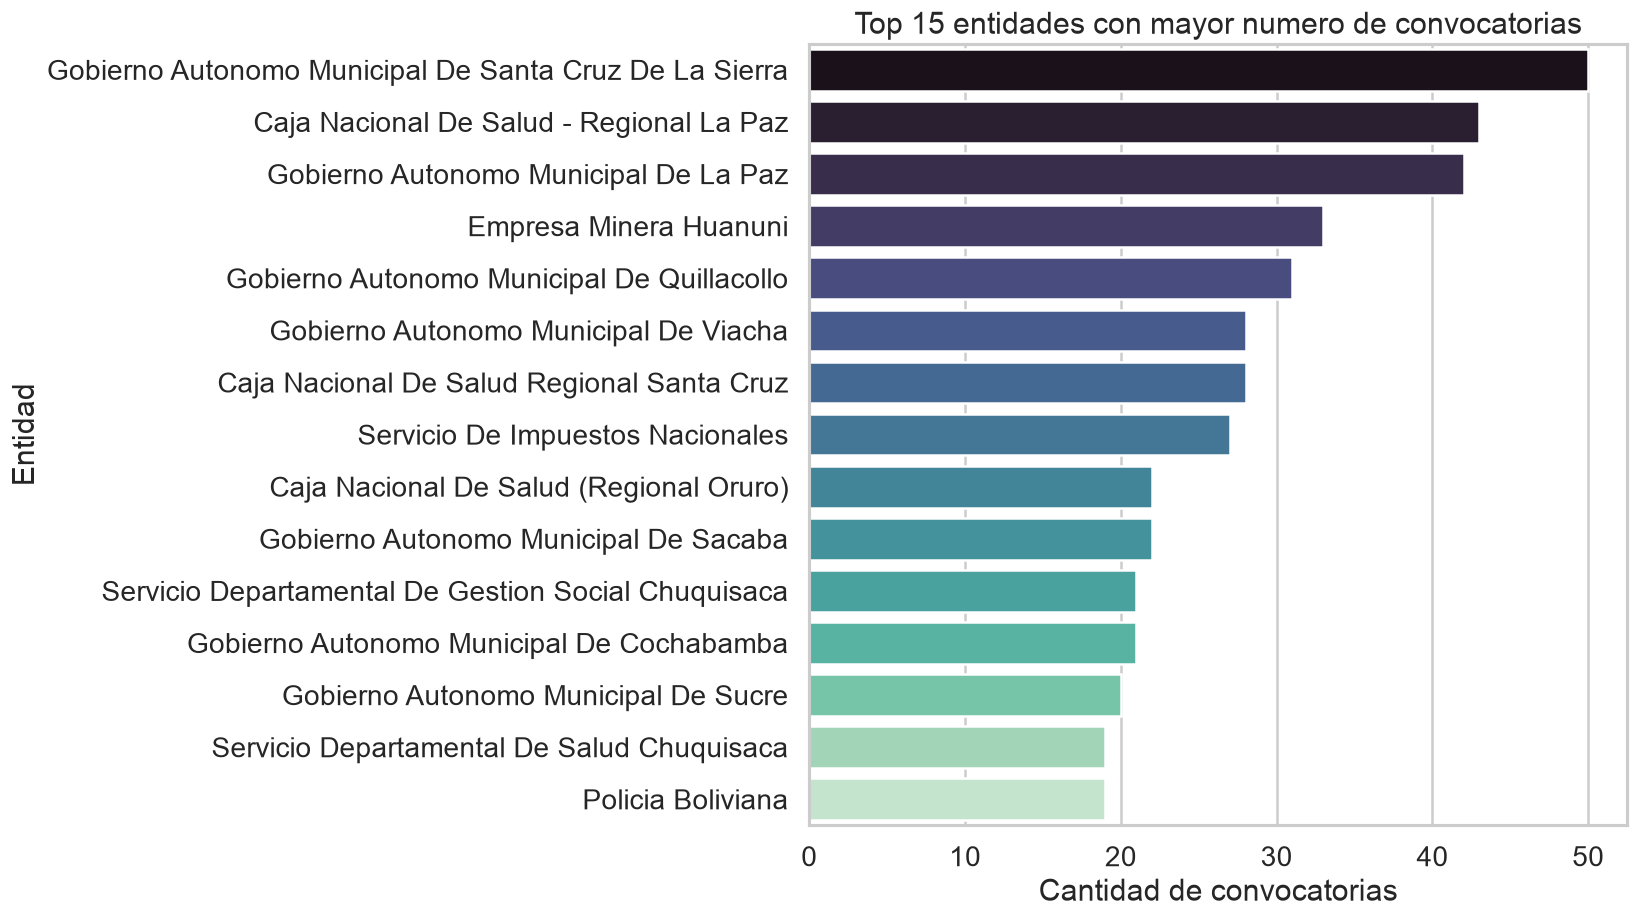

,entidad,cantidad
0,Gobierno Autonomo Municipal De Santa Cruz De L...,50
1,Caja Nacional De Salud - Regional La Paz,43
2,Gobierno Autonomo Municipal De La Paz,42
3,Empresa Minera Huanuni,33
4,Gobierno Autonomo Municipal De Quillacollo,31
5,Gobierno Autonomo Municipal De Viacha,28
6,Caja Nacional De Salud Regional Santa Cruz,28
7,Servicio De Impuestos Nacionales,27
8,Caja Nacional De Salud (Regional Oruro),22
9,Gobierno Autonomo Municipal De Sacaba,22


In [6]:
top_entidades = df["entidad"].fillna("No especificado").value_counts().head(15).reset_index()
top_entidades.columns = ["entidad", "cantidad"]

plt.figure(figsize=(14, 8))
sns.barplot(data=top_entidades, x="cantidad", y="entidad", hue="entidad", palette="mako", legend=False)
plt.title("Top 15 entidades con mayor numero de convocatorias")
plt.xlabel("Cantidad de convocatorias")
plt.ylabel("Entidad")
save_figure("eda_top_entidades.png")
plt.show()

top_entidades


## 4. Distribucion temporal


Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_temporal_distribution.png


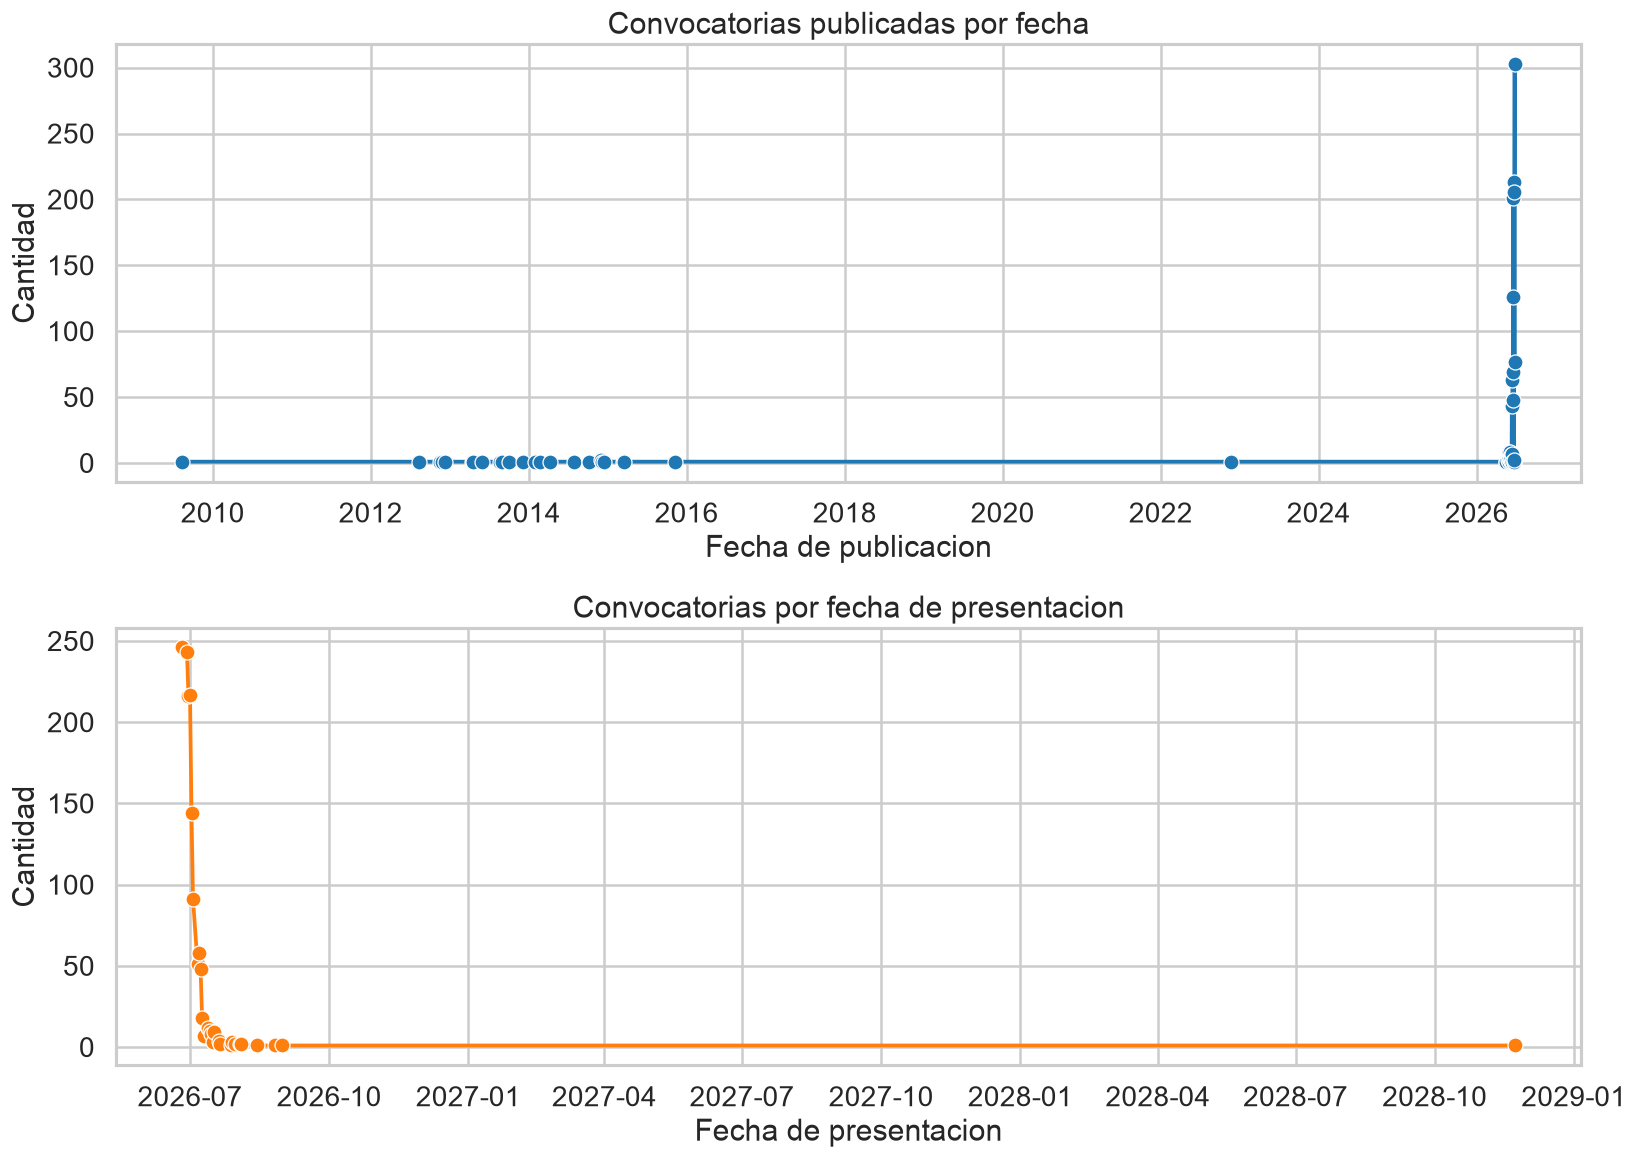

Rango fecha publicacion: 2009-08-14 00:00:00 -> 2026-06-26 00:00:00
Rango fecha presentacion: 2026-06-26 00:00:00 -> 2028-11-23 00:00:00


In [7]:
publication_by_day = (
    df.dropna(subset=["fecha_publicacion_dt"])
    .groupby("fecha_publicacion_dt")
    .size()
    .rename("cantidad")
    .reset_index()
    .sort_values("fecha_publicacion_dt")
)

presentation_by_day = (
    df.dropna(subset=["fecha_presentacion_dt"])
    .groupby("fecha_presentacion_dt")
    .size()
    .rename("cantidad")
    .reset_index()
    .sort_values("fecha_presentacion_dt")
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
sns.lineplot(data=publication_by_day, x="fecha_publicacion_dt", y="cantidad", marker="o", ax=axes[0], color="#1f77b4")
axes[0].set_title("Convocatorias publicadas por fecha")
axes[0].set_xlabel("Fecha de publicacion")
axes[0].set_ylabel("Cantidad")

sns.lineplot(data=presentation_by_day, x="fecha_presentacion_dt", y="cantidad", marker="o", ax=axes[1], color="#ff7f0e")
axes[1].set_title("Convocatorias por fecha de presentacion")
axes[1].set_xlabel("Fecha de presentacion")
axes[1].set_ylabel("Cantidad")

save_figure("eda_temporal_distribution.png")
plt.show()

print("Rango fecha publicacion:", df["fecha_publicacion_dt"].min(), "->", df["fecha_publicacion_dt"].max())
print("Rango fecha presentacion:", df["fecha_presentacion_dt"].min(), "->", df["fecha_presentacion_dt"].max())


## 5. Longitud textual de `objeto_contratacion`


In [8]:
text_metrics = df[["longitud_objeto", "cantidad_palabras_objeto"]].describe().T
text_metrics[["mean", "std", "min", "50%", "max"]]


,mean,std,min,50%,max
longitud_objeto,104.787964,50.616236,1.0,97.0,356.0
cantidad_palabras_objeto,15.531141,7.657216,1.0,14.0,46.0


Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_text_length_distribution.png


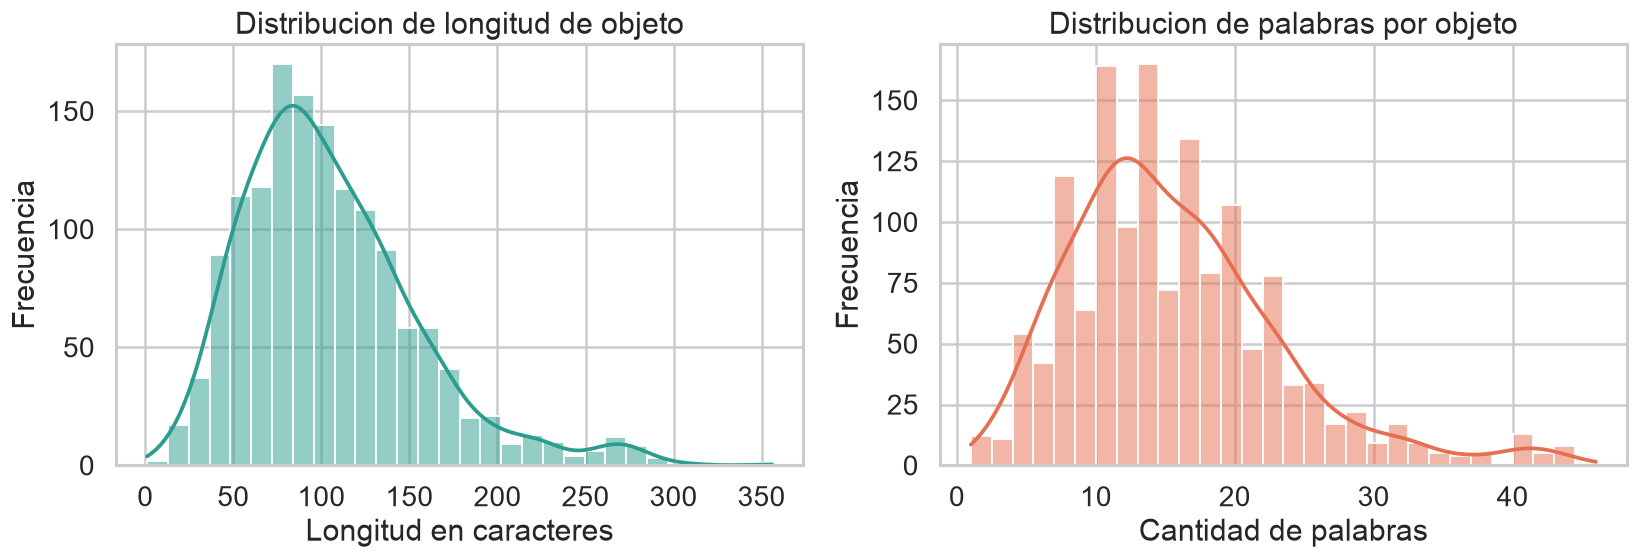

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["longitud_objeto"], bins=30, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Distribucion de longitud de objeto")
axes[0].set_xlabel("Longitud en caracteres")
axes[0].set_ylabel("Frecuencia")

sns.histplot(df["cantidad_palabras_objeto"], bins=30, kde=True, ax=axes[1], color="#e76f51")
axes[1].set_title("Distribucion de palabras por objeto")
axes[1].set_xlabel("Cantidad de palabras")
axes[1].set_ylabel("Frecuencia")

save_figure("eda_text_length_distribution.png")
plt.show()


## 6. Frecuencia de palabras en `objeto_contratacion`

Este analisis ayuda a detectar vocabulario dominante, ruido textual o posibles problemas de normalizacion del campo.
Se comparan dos vistas: una frecuencia bruta de tokens y otra frecuencia normalizada, donde se eliminan anos, numeros, tildes inconsistentes y parte del ruido institucional.
Tambien se agrega una nube de palabras como visual complementaria, sin sustituir las tablas de frecuencia.


In [10]:
raw_tokens = tokenize_raw_text(df["objeto_contratacion"])
raw_word_frequency = pd.DataFrame(Counter(raw_tokens).most_common(20), columns=["palabra", "frecuencia"])

tokens = normalize_text(df["objeto_contratacion"])
word_frequency = pd.DataFrame(Counter(tokens).most_common(20), columns=["palabra", "frecuencia"])

print("Top 10 palabras en bruto:")
display(raw_word_frequency.head(10))
print("Top 20 palabras normalizadas:")
word_frequency


Top 10 palabras en bruto:


,palabra,frecuencia
0,de,2905
1,para,926
2,y,654
3,del,517
4,la,472
5,el,448
6,adquisicion,427
7,2026,343
8,servicio,269
9,adquisición,257


Top 20 palabras normalizadas:


,palabra,frecuencia
0,hospital,222
1,construccion,210
2,compra,140
3,calle,130
4,medicamentos,124
5,insumos,95
6,mantenimiento,84
7,laboratorio,75
8,material,67
9,reactivos,61


Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_top_words_objeto.png


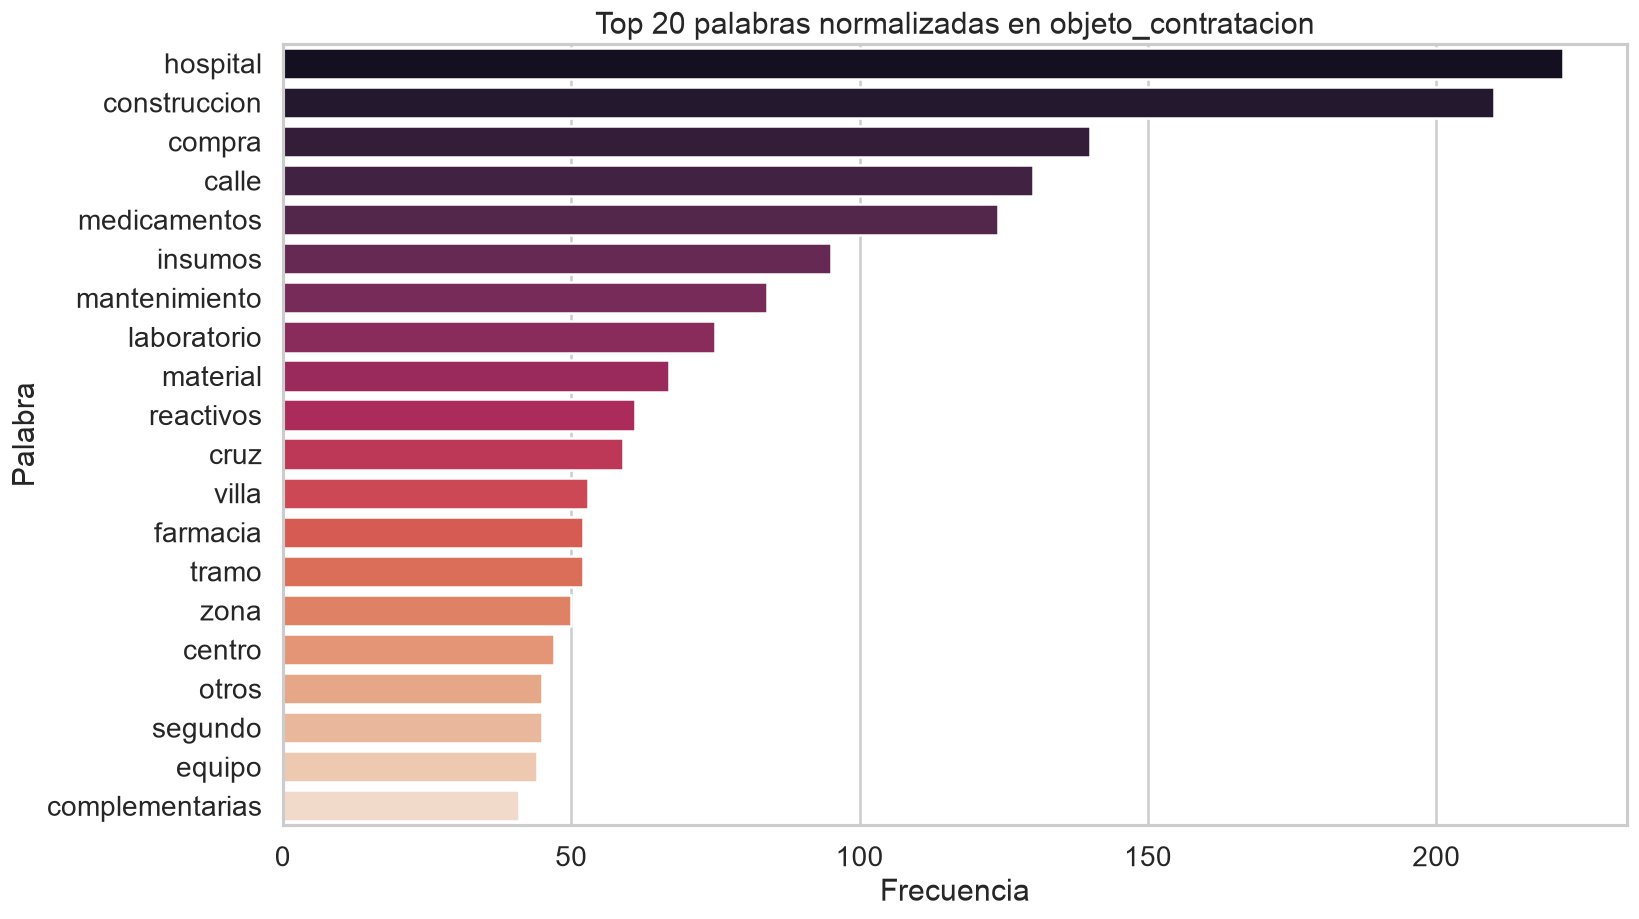

In [11]:
plt.figure(figsize=(14, 8))
sns.barplot(data=word_frequency, x="frecuencia", y="palabra", hue="palabra", palette="rocket", legend=False)
plt.title("Top 20 palabras normalizadas en objeto_contratacion")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
save_figure("eda_top_words_objeto.png")
plt.show()


Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_wordcloud_objeto.png


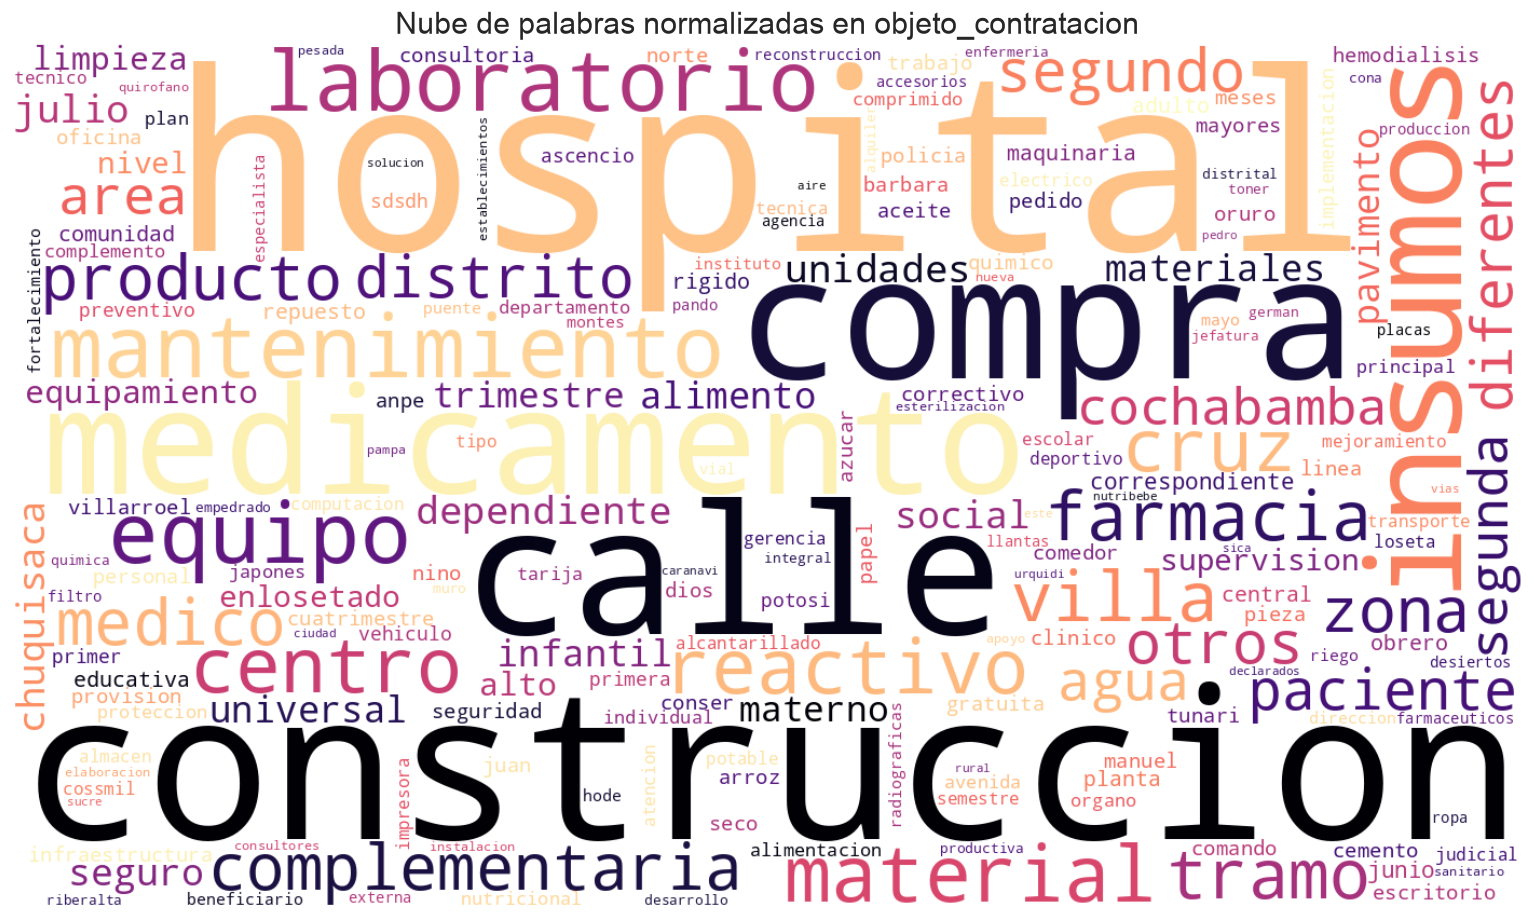

In [12]:
wordcloud_text = " ".join(tokens)
if WordCloud is None:
    print("La libreria `wordcloud` no esta instalada. Ejecuta `uv sync` para habilitar esta figura.")
elif not wordcloud_text.strip():
    print("No hay tokens suficientes para construir la nube de palabras.")
else:
    wordcloud = WordCloud(
        width=1400,
        height=800,
        background_color="white",
        colormap="magma",
        collocations=False,
    ).generate(wordcloud_text)

    plt.figure(figsize=(14, 8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Nube de palabras normalizadas en objeto_contratacion")
    save_figure("eda_wordcloud_objeto.png")
    plt.show()


## 7. Hallazgos preliminares

A partir del EDA se espera validar o refinar decisiones posteriores del pipeline semantico:

- si `cuce` no es unico, se debe revisar la estrategia de deduplicacion antes de embeddings
- si `objeto_contratacion` presenta textos demasiado cortos o repetitivos, conviene enriquecer el contenido para recuperacion semantica
- las distribuciones por modalidad, estado y fechas orientan el sesgo natural del corpus
- las palabras frecuentes, la nube de palabras y los top de entidades ayudan a detectar ruido estructural, abreviaturas y campos mal mapeados

Este notebook produce insumos directos para la redaccion del capitulo metodologico y el analisis de datos de la monografia.
